Importing libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

Reading Data

In [2]:
df = pd.read_csv("../data/raw/reduced_spain_data.csv", index_col=0)
df.head()

,insert_date,origin,destination,start_date,end_date,train_type,price,train_class,fare
Unnamed: 0,,,,,,,,,
1066521,2019-04-30 11:05:12,MADRID,SEVILLA,2019-05-12 11:00:00,2019-05-12 13:32:00,AVE,76.30,Turista,Flexible
1483148,2019-05-08 07:46:28,MADRID,BARCELONA,2019-05-21 15:00:00,2019-05-21 17:30:00,AVE,68.65,Turista,Promo
2038331,2019-04-15 10:35:01,VALENCIA,MADRID,2019-05-20 17:10:00,2019-05-20 18:50:00,AVE,21.95,Turista,Promo
1202217,2019-05-02 23:36:41,MADRID,VALENCIA,2019-05-19 18:40:00,2019-05-19 20:20:00,AVE,73.10,Turista,Flexible
777220,2019-04-25 13:30:29,SEVILLA,MADRID,2019-05-15 13:40:00,2019-05-15 16:10:00,AVE,47.30,Turista,Promo


Four Numeric Stats: Date, Start time, end time, Price
Categorical:Train Class, Origin, Destination, Fare, Train Type
Size : 500,000 Rows

In [3]:
df.info()


<class 'pandas.DataFrame'>
Index: 500000 entries, 1066521 to 1515098
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   insert_date  500000 non-null  str    
 1   origin       500000 non-null  str    
 2   destination  500000 non-null  str    
 3   start_date   500000 non-null  str    
 4   end_date     500000 non-null  str    
 5   train_type   500000 non-null  str    
 6   price        439860 non-null  float64
 7   train_class  498163 non-null  str    
 8   fare         498163 non-null  str    
dtypes: float64(1), str(8)
memory usage: 38.1 MB


In [4]:
df["start_date"]=pd.to_datetime(df["start_date"],errors="coerce") # covert time to Datetime
df["end_date"]=pd.to_datetime(df["end_date"],errors="coerce") # covert time to Datetime
df['price'] = pd.to_numeric(df["price"], errors= "coerce")# convert to numeric


In [5]:
df = df.drop(columns = ["insert_date"]) # doesn't add much, same for all

In [6]:
df.info()

<class 'pandas.DataFrame'>
Index: 500000 entries, 1066521 to 1515098
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   origin       500000 non-null  str           
 1   destination  500000 non-null  str           
 2   start_date   500000 non-null  datetime64[us]
 3   end_date     500000 non-null  datetime64[us]
 4   train_type   500000 non-null  str           
 5   price        439860 non-null  float64       
 6   train_class  498163 non-null  str           
 7   fare         498163 non-null  str           
dtypes: datetime64[us](2), float64(1), str(5)
memory usage: 34.3 MB


In [7]:
#describe data set
df["price"].describe().round(2)

count    439860.00
mean         63.39
std          25.78
min          15.45
25%          43.75
50%          60.30
75%          78.80
max         214.20
Name: price, dtype: float64

Explain the describing here 

In [8]:
df.isna().sum() # check for missing data

origin             0
destination        0
start_date         0
end_date           0
train_type         0
price          60140
train_class     1837
fare            1837
dtype: int64

Replaced na in price with the avg

In [9]:
avg=df.groupby(["origin"])["price"].mean()

In [10]:
df["price"] = df["price"].fillna(df.groupby("origin")["price"].transform("mean"))

In [11]:
df.dropna(subset=["price", "train_type", "train_class"]) # remove na values in the columns train and class

,origin,destination,start_date,end_date,train_type,price,train_class,fare
Unnamed: 0,,,,,,,,
1066521,MADRID,SEVILLA,2019-05-12 11:00:00,2019-05-12 13:32:00,AVE,76.300000,Turista,Flexible
1483148,MADRID,BARCELONA,2019-05-21 15:00:00,2019-05-21 17:30:00,AVE,68.650000,Turista,Promo
2038331,VALENCIA,MADRID,2019-05-20 17:10:00,2019-05-20 18:50:00,AVE,21.950000,Turista,Promo
1202217,MADRID,VALENCIA,2019-05-19 18:40:00,2019-05-19 20:20:00,AVE,73.100000,Turista,Flexible
777220,SEVILLA,MADRID,2019-05-15 13:40:00,2019-05-15 16:10:00,AVE,47.300000,Turista,Promo
...,...,...,...,...,...,...,...,...
1779181,MADRID,SEVILLA,2019-05-31 11:05:00,2019-05-31 13:41:00,ALVIA,64.073827,Turista,Promo
1970095,BARCELONA,MADRID,2019-05-13 07:25:00,2019-05-13 10:01:00,AVE,107.700000,Turista,Flexible
2285307,MADRID,SEVILLA,2019-05-22 21:25:00,2019-05-23 00:10:00,AV City,49.150000,Turista,Promo


In [12]:
df.isna().sum() # check again if null values exist

origin            0
destination       0
start_date        0
end_date          0
train_type        0
price             0
train_class    1837
fare           1837
dtype: int64

Adding days

In [13]:
df = df.reset_index() #ordering them after removing

function to calculate trip time

In [14]:
df["Day"] = df["start_date"].dt.day_name()

In [15]:
datetimeFormat = '%Y-%m-%d %H:%M:%S'
def fun(a,b):
    diff = b - a
    return(diff.seconds/3600.0)

In [16]:
df["Trip duration"] = df.apply(lambda x:fun(x['start_date'],x['end_date']),axis=1) 

adding the trip duration

In [17]:
df["Month"]=df["start_date"].dt.month
df["year"]=df["start_date"].dt.year
df["hour"] = df['start_date'].dt.hour


categorizing by month day and year

In [18]:
df.head()

,Unnamed: 0,origin,destination,start_date,end_date,train_type,price,train_class,fare,Day,Trip duration,Month,year,hour
0,1066521,MADRID,SEVILLA,2019-05-12 11:00:00,2019-05-12 13:32:00,AVE,76.30,Turista,Flexible,Sunday,2.533333,5,2019,11
1,1483148,MADRID,BARCELONA,2019-05-21 15:00:00,2019-05-21 17:30:00,AVE,68.65,Turista,Promo,Tuesday,2.500000,5,2019,15
2,2038331,VALENCIA,MADRID,2019-05-20 17:10:00,2019-05-20 18:50:00,AVE,21.95,Turista,Promo,Monday,1.666667,5,2019,17
3,1202217,MADRID,VALENCIA,2019-05-19 18:40:00,2019-05-19 20:20:00,AVE,73.10,Turista,Flexible,Sunday,1.666667,5,2019,18
4,777220,SEVILLA,MADRID,2019-05-15 13:40:00,2019-05-15 16:10:00,AVE,47.30,Turista,Promo,Wednesday,2.500000,5,2019,13


Line plot: Average ticket price over time by depart date

Grouped by start date of the trip to display overall trends. Modified to include a rolling average to highlight the general trend while reducing short-term fluctuations.

87
   start_date      price
0  2019-04-12  76.708052
1  2019-04-13  68.717691
2  2019-04-14  73.382845
3  2019-04-15  68.616825
4  2019-04-16  68.940097


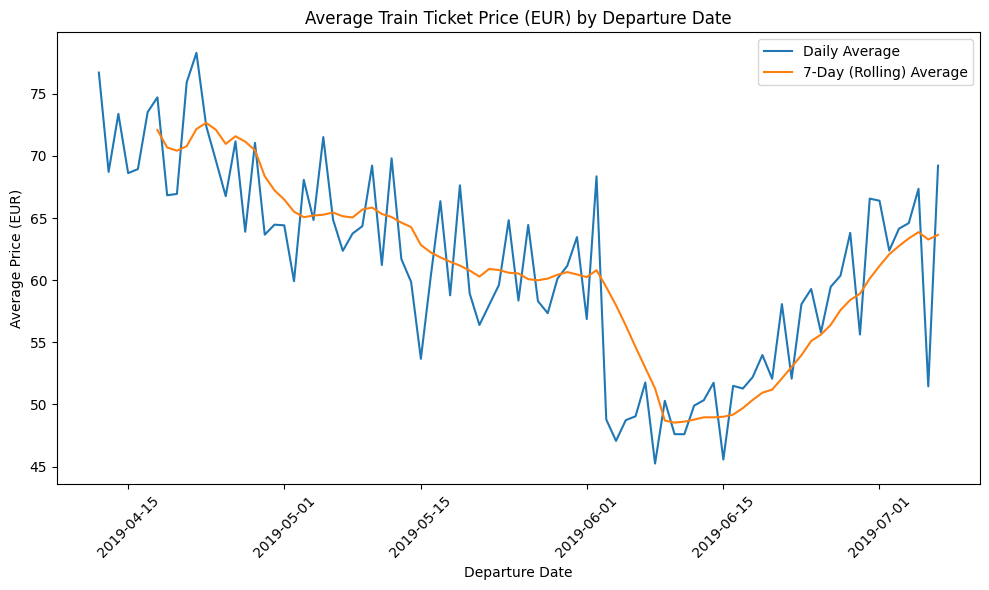

In [19]:
grouped = df.groupby(df["start_date"].dt.date)["price"].mean().reset_index()
grouped.columns = ["start_date", "price"]

grouped = grouped.sort_values("start_date")

print(len(grouped))
print(grouped.head())

grouped["rolling_average"] = grouped["price"].rolling(window=7).mean()

plt.figure(figsize=(10,6))
sns.lineplot(data=grouped, x="start_date", y="price", label="Daily Average")
sns.lineplot(data=grouped, x="start_date", y="rolling_average", label="7-Day (Rolling) Average")

plt.title("Average Train Ticket Price (EUR) by Departure Date")
plt.xlabel("Departure Date")
plt.ylabel("Average Price (EUR)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../figures/line_plot.png", dpi=300)
plt.show()

Bar plot: average ticket price by train type

Grouped by train type, modified to include specific mean values atop each bar for each train type

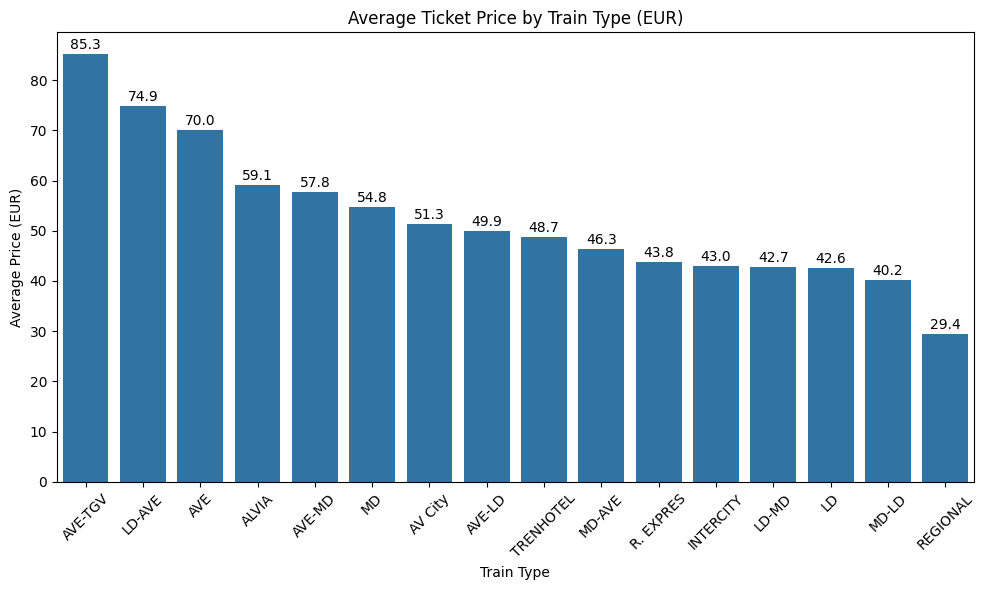

In [20]:
avg_price_by_type = (
    df.groupby("train_type")["price"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))
avg_price_by_type = avg_price_by_type.reset_index()

sns.barplot(data=avg_price_by_type, x="train_type", y="price")

plt.title("Average Ticket Price by Train Type (EUR)")
plt.xlabel("Train Type")
plt.ylabel("Average Price (EUR)")
plt.xticks(rotation=45)
plt.tight_layout()

for i, v in enumerate(avg_price_by_type["price"]):
    plt.text(i, v + 1, f"{v:.1f}", ha='center')

plt.savefig("../figures/bar_plot.png", dpi=300)
plt.show()

Busiest days of the week, and hours

Info regarding trip length by City
explanation.....

In [21]:
df.groupby('origin')['Trip duration'].agg(['count', 'mean', 'median', 'min', 'max'])



,count,mean,median,min,max
origin,,,,,
BARCELONA,78444,3.140841,2.750000,2.500000,11.366667
MADRID,263943,3.087501,2.633333,1.666667,11.250000
PONFERRADA,18127,5.182833,5.000000,4.066667,8.066667
SEVILLA,77031,2.885678,2.533333,2.350000,12.416667
VALENCIA,62455,3.320029,1.866667,1.633333,7.700000


In [22]:
DaysHoursTable = df.pivot_table(
    index='Day',
    columns='hour',
    aggfunc='size',
    fill_value=0
)

DaysHoursTable = DaysHoursTable.reindex([
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
])

Matrix

In [23]:
DaysHoursTable

hour,2,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22
Day,,,,,,,,,,,,,,,,,,,
Monday,347,878,6612,6198,4607,5362,2652,3986,4662,3061,4912,4482,5659,5296,3929,3962,3201,2701,363
Tuesday,341,383,6806,6432,4823,6110,2815,4066,4748,3081,5140,4726,5701,5313,4001,4069,3253,2745,354
Wednesday,373,278,5768,5904,4580,6074,2822,3963,4468,3258,5255,4476,5238,5428,3921,5006,3107,2817,288
Thursday,290,865,6375,6474,4870,5709,2850,4086,5040,3284,5347,4699,5584,5351,4073,5093,3953,2855,300
Friday,231,567,5890,3983,4156,5894,2923,3604,4542,3332,5927,5049,6111,6185,4783,5319,4205,3266,235
Saturday,244,0,1754,2623,6219,5126,3303,4471,3512,2532,4186,3255,2952,3176,2242,3164,2170,2639,0
Sunday,0,2,1984,2080,4043,3860,2620,4489,4361,3546,5792,4195,6643,8126,5771,5797,4935,3747,340


In [24]:
df.groupby(['Day', 'hour']).size().sort_values(ascending=False)

Day        hour
Sunday     17      8126
Tuesday    6       6806
Sunday     16      6643
Monday     6       6612
Thursday   7       6474
                   ... 
Wednesday  5        278
Saturday   2        244
Friday     22       235
           2        231
Sunday     5          2
Length: 130, dtype: int64

Scatter plot

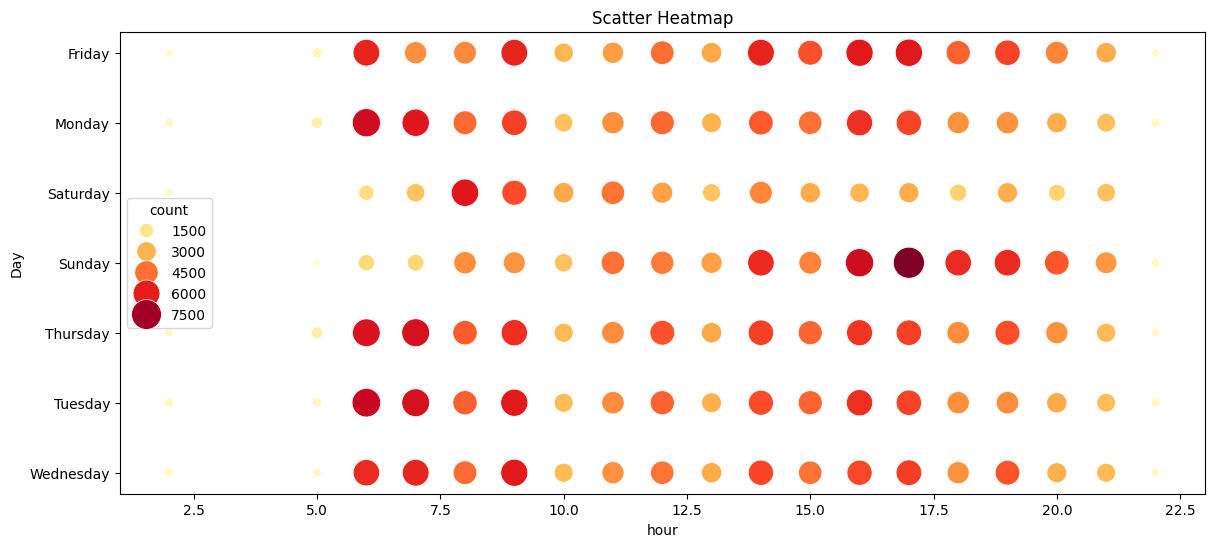

In [25]:
agg = df.groupby(['Day', 'hour']).size().reset_index(name='count')
plt.figure(figsize=(14,6))

sns.scatterplot(
    data=agg,
    x='hour',
    y='Day',
    size='count',
    hue='count',
    palette='YlOrRd',
    sizes=(20, 500)
)

plt.title("Scatter Heatmap")
plt.savefig("../figures/scatter_plot.png", dpi=300)
plt.show()

Trip Duration Distribution

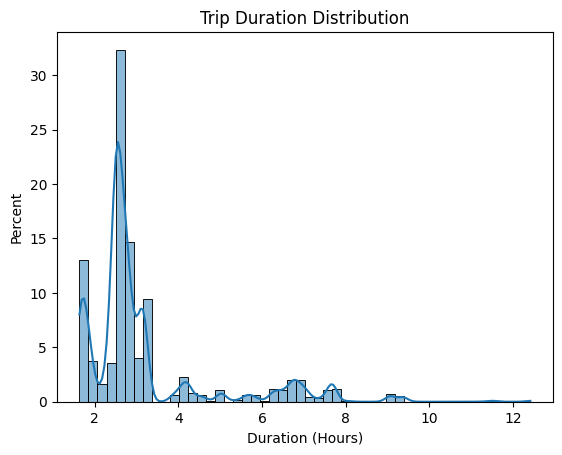

In [26]:
sns.histplot(df['Trip duration'], bins=50,stat ='percent', kde = True)
plt.xlabel("Duration (Hours)")
plt.title("Trip Duration Distribution")
plt.savefig("../figures/histogram.png", dpi=300)
plt.show()

### Exploratory Data Analysis (EDA)

In [27]:
# describe general overview of numeric columns
df[['price', 'Trip duration']].describe().round(2)

,price,Trip duration
count,500000.00,500000.00
mean,63.24,3.17
std,24.32,1.65
min,15.45,1.63
25%,45.30,2.50
50%,62.49,2.63
75%,76.30,3.17
max,214.20,12.42


In [28]:

# Explicitly describe stats on key column
print("Price Statistics:")
print(f"MEAN:   {df["price"].mean():.2f}")
print(F"MEDIAN: {df["price"].median():.2f}")
print(f"STD:    {df["price"].std():.2f}")
print(f"MIN:    {df["price"].min():.2f}")
print(f"MAX:    {df["price"].max():.2f}")


Price Statistics:
MEAN:   63.24
MEDIAN: 62.49
STD:    24.32
MIN:    15.45
MAX:    214.20


From the table, we see that ticket prices range from 15.45 to 214.20, with an average of 63.24 and median of 62.49. The fact that the mean and the median are very close together suggests that the price distribution is fairly symmetric, without any outliers that heavily skew the average one way. Also, the standard deviation (24.32) tells us that there is a moderate spread around the mean.

In [29]:

# Group stats by categorical variable
df.groupby('train_class')['price'].agg(['mean', 'median', 'std', 'min', 'max']).round(2)

,mean,median,std,min,max
train_class,,,,,
Cama G. Clase,128.97,150.60,38.00,64.07,150.6
Cama Turista,73.69,74.20,2.22,64.07,74.2
Preferente,79.19,69.40,28.64,27.70,214.2
Turista,60.95,62.20,22.75,16.60,172.4
Turista Plus,81.88,82.35,20.23,15.45,206.8
Turista con enlace,44.67,42.03,12.07,21.65,71.0


As seen in the table, ticket prices can vary considerably by train class. The most expensive class on average is <i>Cama G. Clase</i> (128.97), followed by <i>Cama Turista</i>, and then <i>Preferente</i>. The standard <i>Turista con Enlace</i> is the cheapest at 44.67, which confirms that train class is strongly driven by ticket price.

In [30]:
# Compute the correlation matrix using price, trip duration, month, and hour
numeric_cols = ['price', 'Trip duration', 'Month', 'hour']
matrix = df[numeric_cols].corr().round(2)
matrix

,price,Trip duration,Month,hour
price,1.00,-0.29,-0.13,0.08
Trip duration,-0.29,1.00,0.11,-0.19
Month,-0.13,0.11,1.00,-0.02
hour,0.08,-0.19,-0.02,1.00


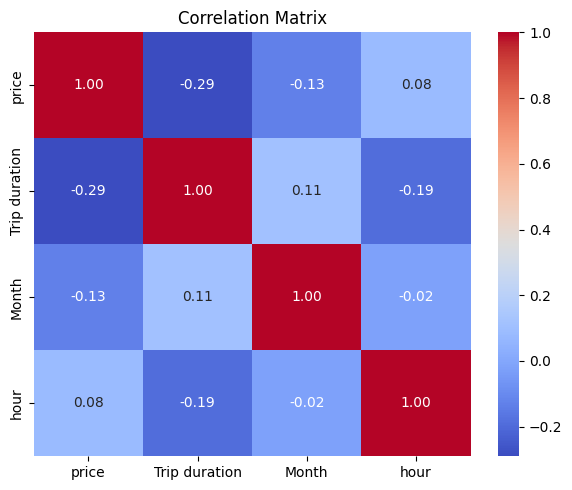

In [31]:
# Visualize correlation matrix with a heatmap
fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(matrix, annot=True, fmt='.2f', cmap="coolwarm", ax=ax)

ax.set_title("Correlation Matrix")
fig.tight_layout()
fig.savefig("../figures/correlation_heatmap.png", dpi=300)
plt.show()

As observed in the figure, none of the numeric variables really has a strong linear relationship with price. The most notable correlation that we can draw from this figure is between <u><b>price and trip duration (-0.29)</u></b>, which indicates that longer trips are usually slighly cheaper. All other correlations are not necessarily worth noting, as they are very close to 0 (no correlation).

#### Simple Feature Exploration
Questions:
1. Does fare type (Promo vs Flexible) affect the price (significantly)?
2. Do weekdays have different average prices than weekends?

In [32]:
# Question 1: Does fare type (Promo vs Flexible) affect the price (significantly)?
fare_stats = df.groupby('fare')['price'].agg(['mean', 'median', 'std', 'min', 'max']).round(2)
fare_stats

,mean,median,std,min,max
fare,,,,,
Adulto ida,32.25,28.35,8.33,28.35,84.62
Flexible,77.91,76.30,24.69,39.91,214.20
Individual-Flexible,128.97,150.60,38.00,64.07,150.60
Mesa,148.65,172.40,68.30,64.07,206.80
Promo,62.61,62.49,21.56,15.45,169.20
Promo +,38.31,34.35,7.42,28.10,106.75


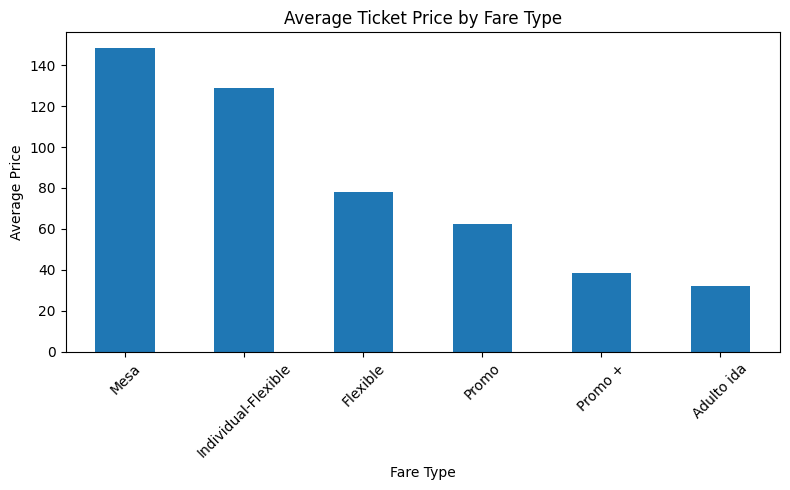

In [33]:
fig, ax = plt.subplots(figsize=(8,5))

fare_stats['mean'].sort_values(ascending=False).plot(kind='bar', ax=ax)

ax.set_title("Average Ticket Price by Fare Type")
ax.set_xlabel("Fare Type")
ax.set_ylabel("Average Price")
plt.xticks(rotation=45)
fig.tight_layout()
fig.savefig("../figures/price_by_fare.png", dpi=300)
plt.show()

As seen in the figure, flexible fare tickets are not on average significantly more expensive than regular promo. However, compared to Promo + tickets, they <u><b>are</u></b> more expensive, on average (40+ euros). This suggests that pricing flexibility does come at a premium, with promo fares offering lowest prices but likely with less premium conditions. 

In [34]:
# Question 2: Do weekdays have different average prices than weekends?

weekend_days = ['Saturday', 'Sunday']
df['day_type'] = df['Day'].apply(lambda i : 'Weekend' if i in weekend_days else 'Weekday')
day_type_stats = df.groupby('day_type')['price'].agg(['mean', 'median', 'std', 'min', 'max']).round(2)
day_type_stats

,mean,median,std,min,max
day_type,,,,,
Weekday,62.59,62.49,24.56,15.45,214.2
Weekend,65.15,64.07,23.51,16.60,214.2


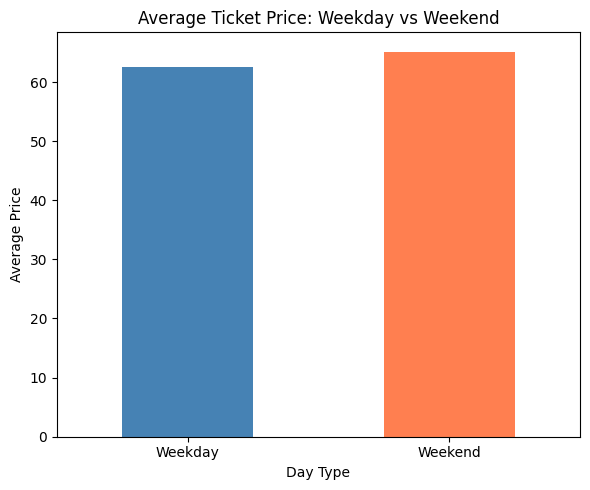

In [35]:
fig, ax = plt.subplots(figsize=(6, 5))

day_type_stats['mean'].plot(kind='bar', ax=ax, color=['steelblue', 'coral'])

ax.set_title("Average Ticket Price: Weekday vs Weekend")
ax.set_xlabel("Day Type")
ax.set_ylabel("Average Price")
plt.xticks(rotation=0)
fig.tight_layout()
fig.savefig("../figures/price_weekday_vs_weekend.png", dpi=300)
plt.show()

As seen in the figure, weekend tickets tend to <b><u>slightly more</b></u> expensive than weekday, but not by much (2-3 euros at most) on average. This suggests that demand can be slighly higher during weekends than weekdays.